In [1]:
!pip install pulp matplotlib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import random
import csv
import matplotlib.pyplot as plt
import numpy as np
from pulp import LpProblem, LpVariable, LpMaximize, lpSum, value, LpStatus

### UTA

In [ ]:
prob = LpProblem("UTA", LpMaximize)

n_characteristic_points = 4
file = csv.reader(open("Nuclear waste management.csv"))
raw_data = list(file)
data = {}
for row in raw_data[1:]:
    alt_id = row[0]
    data[alt_id] = [float(val) for val in row[1:]]

variants = [4, 6, 7, 11, 13, 14, 20, 25, 27]

G = []
for i in range(4):
    unique_vals = sorted([data[k][i] for k in data.keys()])
    G.append(unique_vals)

prob = LpProblem("True_UTA_Model", LpMaximize)
epsilon = LpVariable("epsilon", lowBound=0)
prob += epsilon, "Maximize_Epsilon"
omega = LpVariable("omega", lowBound=0.01)

u = [{} for _ in range(4)]
characteristic_points = {}
for i in range(4):
    u[i] = {}
    characteristic_points[i] = []
    for j in range(1, n_characteristic_points + 1):
        point = round(G[i][0] + (j - 1) / (n_characteristic_points - 1) * (G[i][-1] - G[i][0]), 2)
        characteristic_points[i].append(point)
        var_name = f"u_C{i+1}_{str(point).replace('.', '_')}"
        if point not in u[i]:
            u[i][point] = LpVariable(var_name, lowBound=0)

    characteristic_points[i] = sorted(set(characteristic_points[i]))

print("Characteristic points for each criterion:")
for i in range(4):
    print(f"  Criterion {i+1}: {characteristic_points[i]}")
    print(f"  Corresponding utility variables:")
    for point in characteristic_points[i]:
        print(f"    u({point}) -> {u[i][point].name}")

def get_u_interpolated(criterion_idx, eval_val):
    cps = characteristic_points[criterion_idx]
    
    if eval_val <= cps[0]: return u[criterion_idx][cps[0]]
    if eval_val >= cps[-1]: return u[criterion_idx][cps[-1]]
    
    for j in range(len(cps) - 1):
        if cps[j] <= eval_val <= cps[j+1]:
            x_current = cps[j]
            x_next = cps[j+1]
            
            if x_current == x_next:
                return u[criterion_idx][x_current]
            
            u_current = u[criterion_idx][x_current]
            u_next = u[criterion_idx][x_next]
            
            proportion = (eval_val - x_current) / (x_next - x_current)
            return u_current + proportion * (u_next - u_current)

pairs = [('14', '25'), ('14', '11'), ('13', '20'), ('4', '27'), ('6', '7')]
for a, b in pairs:
    u_a = lpSum([get_u_interpolated(i, data[str(a)][i]) for i in range(4)])
    u_b = lpSum([get_u_interpolated(i, data[str(b)][i]) for i in range(4)])
    
    prob += u_a - u_b >= epsilon, f"Pref_{a}_{b}"

prob += lpSum([u[i][G[i][-1]] for i in range(4)]) == 1, "Normalize_Sum_Max"
for i in range(4):
    prob += u[i][G[i][0]] == 0, f"Min_Zero_C{i+1}"

for i in range(4):
    for j in range(1, n_characteristic_points):
        prob += u[i][characteristic_points[i][j]] >= u[i][characteristic_points[i][j-1]] + omega, f"Monotonicity_C{i+1}_CP{j}"

prob.solve()
print(f"Solver Status: {LpStatus[prob.status]}\n")
if prob.status == 1:
    print(f"Maximized Epsilon (ε): {value(epsilon):.4f}\n")
    

    for i in range(4):
        print(f"\nPartial utility function for Criterion {i+1}:")
        for val in characteristic_points[i]:
            print(f"  u({val}) = {value(u[i][val]):.4f}")
else:
    print("Model is Infeasible.")


Characteristic points for each criterion:
  Criterion 1: [0.32, 0.55, 0.77, 1.0]
  Corresponding utility variables:
    u(0.32) -> u_C1_0_32
    u(0.55) -> u_C1_0_55
    u(0.77) -> u_C1_0_77
    u(1.0) -> u_C1_1_0
  Criterion 2: [0.03, 0.35, 0.68, 1.0]
  Corresponding utility variables:
    u(0.03) -> u_C2_0_03
    u(0.35) -> u_C2_0_35
    u(0.68) -> u_C2_0_68
    u(1.0) -> u_C2_1_0
  Criterion 3: [0.0, 0.33, 0.67, 1.0]
  Corresponding utility variables:
    u(0.0) -> u_C3_0_0
    u(0.33) -> u_C3_0_33
    u(0.67) -> u_C3_0_67
    u(1.0) -> u_C3_1_0
  Criterion 4: [0.49, 0.66, 0.83, 1.0]
  Corresponding utility variables:
    u(0.49) -> u_C4_0_49
    u(0.66) -> u_C4_0_66
    u(0.83) -> u_C4_0_83
    u(1.0) -> u_C4_1_0
Solver Status: Optimal

Maximized Epsilon (ε): 0.1319


Partial utility function for Criterion 1:
  u(0.32) = 0.0000
  u(0.55) = 0.0209
  u(0.77) = 0.3633
  u(1.0) = 0.3733

Partial utility function for Criterion 2:
  u(0.03) = 0.0000
  u(0.35) = 0.4477
  u(0.68) = 0.5432


In [34]:
necessary_preferences = [('14', '25'), ('14', '11'), ('13', '20'), ('4', '27'), ('6', '7')]
for i in range(1, len(data.keys()) + 1):
    for j in range(1, len(data.keys()) + 1):
        if (str(i), str(j)) in pairs or (str(j), str(i)) in pairs or i == j:
            continue
        prob = LpProblem("UTAGMS", LpMaximize)
        epsilon = LpVariable("epsilon", lowBound=0)
        prob += epsilon, "Maximize_Epsilon"

        omega = LpVariable("omega", lowBound=0.00)

        _variants = variants + [i, j]
        u = [{} for _ in range(4)]
        characteristic_points = {}
        for k in range(4):
            u[k] = {}
            characteristic_points[k] = []
            for l in range(1, n_characteristic_points + 1):
                point = round(G[k][0] + (l - 1) / (n_characteristic_points - 1) * (G[k][-1] - G[k][0]), 2)
                characteristic_points[k].append(point)
                var_name = f"u_C{k+1}_{str(point).replace('.', '_')}"
                if point not in u[k]:
                    u[k][point] = LpVariable(var_name, lowBound=0)

            characteristic_points[k] = sorted(set(characteristic_points[k]))

        def get_u_interpolated(criterion_idx, eval_val):
            cps = characteristic_points[criterion_idx]
            
            if eval_val <= cps[0]: return u[criterion_idx][cps[0]]
            if eval_val >= cps[-1]: return u[criterion_idx][cps[-1]]
            
            for k in range(len(cps) - 1):
                if cps[k] <= eval_val <= cps[k+1]:
                    x_current = cps[k]
                    x_next = cps[k+1]
                    
                    if x_current == x_next:
                        return u[criterion_idx][x_current]
                    
                    u_current = u[criterion_idx][x_current]
                    u_next = u[criterion_idx][x_next]
                    
                    proportion = (eval_val - x_current) / (x_next - x_current)
                    return u_current + proportion * (u_next - u_current)
                
        _pairs = pairs + [(str(j), str(i))]
        for a, b in _pairs:
            u_a = lpSum([get_u_interpolated(k, data[str(a)][k]) for k in range(4)])
            u_b = lpSum([get_u_interpolated(k, data[str(b)][k]) for k in range(4)])
            
            prob += u_a - u_b >= epsilon, f"Pref_{a}_{b}"

        prob += lpSum([u[k][G[k][-1]] for k in range(4)]) == 1, "Normalize_Sum_Max"
        for k in range(4):
            prob += u[k][G[k][0]] == 0, f"Min_Zero_C{k+1}"

        for k in range(4):
            for l in range(1, n_characteristic_points):
                prob += u[k][characteristic_points[k][l]] >= u[k][characteristic_points[k][l-1]] + omega, f"Monotonicity_C{k+1}_CP{l}"
                prob += u[k][characteristic_points[k][l]] + omega <= u[k][G[k][-1]], f"Monotonicity_C{k+1}_CP{l}_max"
                prob += u[k][characteristic_points[k][l]] + omega >= u[k][G[k][0]], f"Monotonicity_C{k+1}_CP{l}_min"

        prob.solve()
        if prob.status == 1:
            if value(epsilon) <= 1e-6:
                necessary_preferences.append((str(i), str(j)))
        elif prob.status == -1:
            necessary_preferences.append((str(i), str(j)))
        else:
            print(f"Model failed with status {LpStatus[prob.status]} for pair ({str(i)}, {str(j)}).")

essential_pairs = necessary_preferences

In [35]:
print("\nNecessary Preferences:")
for pref in necessary_preferences:
    print(f"  {pref[0]} > {pref[1]}")


Necessary Preferences:
  14 > 25
  14 > 11
  13 > 20
  4 > 27
  6 > 7
  1 > 4
  1 > 10
  1 > 18
  1 > 24
  1 > 27
  2 > 11
  3 > 5
  4 > 10
  4 > 18
  4 > 24
  13 > 4
  13 > 7
  13 > 10
  13 > 16
  13 > 18
  13 > 24
  13 > 27
  14 > 5
  14 > 8
  14 > 22
  16 > 7
  17 > 5
  19 > 22
  21 > 12
  21 > 23
  25 > 22
  26 > 20
  26 > 23
  27 > 18
  27 > 24


In [36]:
import networkx as nx

In [37]:
def build_preference_graph(preferences):
    Gr = nx.DiGraph()
    Gr.add_edges_from(preferences)
    Gr.add_nodes_from([str(i) for i in range(1, len(data.keys()) + 1)])

    Hasse_Graph = nx.transitive_reduction(Gr)

    pos = {}
    for layer, nodes in enumerate(nx.topological_generations(Hasse_Graph)):
        x_offset = (len(nodes) - 1) / 2.0 
        for i, node in enumerate(nodes):
            pos[node] = (i - x_offset, -layer) 

    # 4. Draw the Graph
    plt.figure(figsize=(18, 12))

    nx.draw(
        Hasse_Graph, 
        pos, 
        with_labels=True, 
        node_size=2000, 
        node_color="lightblue", 
        font_size=12, 
        font_weight="bold", 
        arrows=True, 
        arrowsize=20,
        edge_color="gray"
    )

    plt.title("Hasse Diagram of Necessary Preferences (Top-Down)", fontsize=14)
    plt.show()

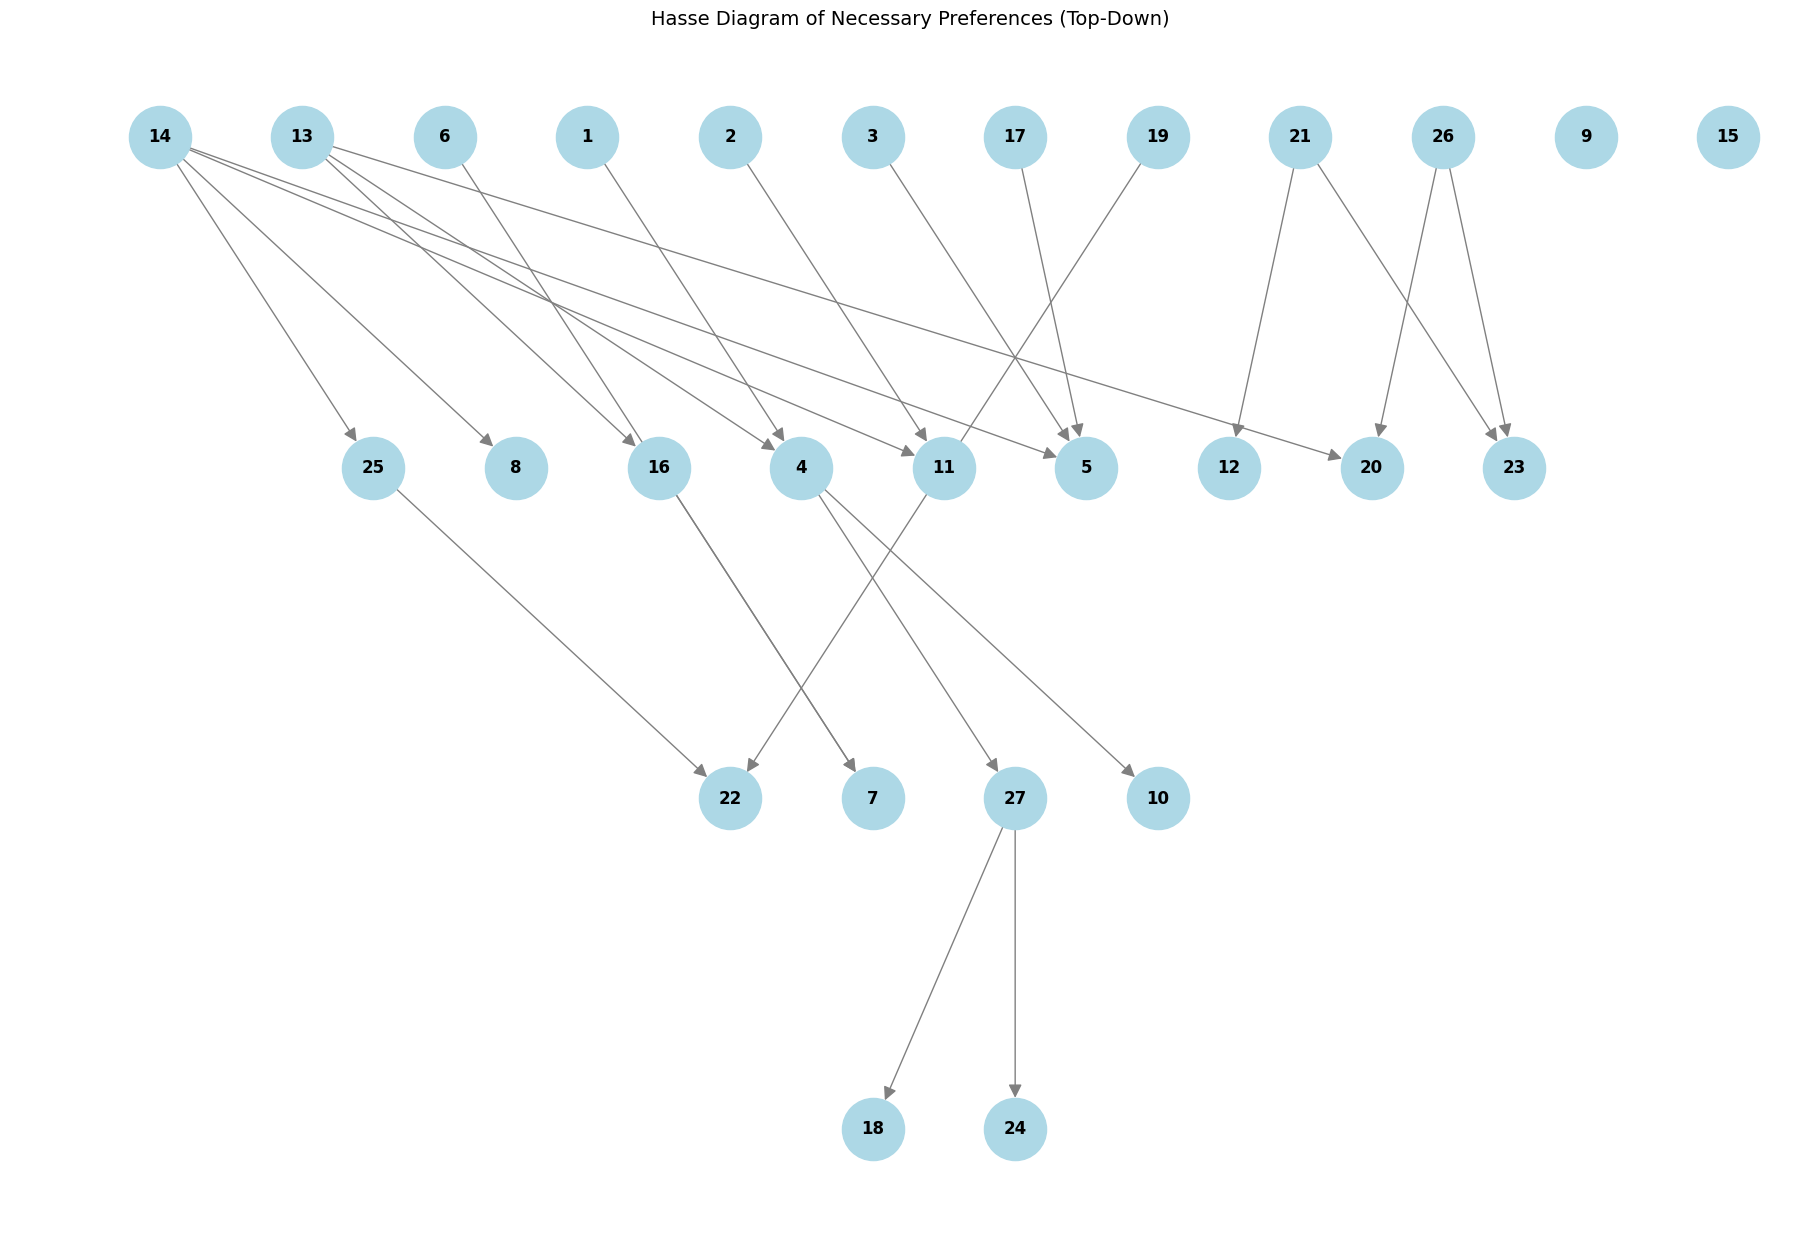

In [38]:
build_preference_graph(essential_pairs)

In [42]:
pairs = necessary_preferences.copy()
prob = LpProblem("UTAGMS", LpMaximize)
# epsilon = LpVariable("epsilon", lowBound=0)
epsilon = 0.1319- 1e-5 - 0.2
delta = LpVariable("delta", lowBound=0)
M = 1000
prob += M * epsilon - delta, "Representative_Function"

omega = LpVariable("omega", lowBound=0.00)

u = [{} for _ in range(4)]
characteristic_points = {}
for k in range(4):
    u[k] = {}
    characteristic_points[k] = []
    for l in range(1, n_characteristic_points + 1):
        point = round(G[k][0] + (l - 1) / (n_characteristic_points - 1) * (G[k][-1] - G[k][0]), 2)
        characteristic_points[k].append(point)
        var_name = f"u_C{k+1}_{str(point).replace('.', '_')}"
        if point not in u[k]:
            u[k][point] = LpVariable(var_name, lowBound=0)

    characteristic_points[k] = sorted(set(characteristic_points[k]))

def get_u_interpolated(criterion_idx, eval_val):
    cps = characteristic_points[criterion_idx]
    
    if eval_val <= cps[0]: return u[criterion_idx][cps[0]]
    if eval_val >= cps[-1]: return u[criterion_idx][cps[-1]]
    
    for k in range(len(cps) - 1):
        if cps[k] <= eval_val <= cps[k+1]:
            x_current = cps[k]
            x_next = cps[k+1]
            
            if x_current == x_next:
                return u[criterion_idx][x_current]
            
            u_current = u[criterion_idx][x_current]
            u_next = u[criterion_idx][x_next]
            
            proportion = (eval_val - x_current) / (x_next - x_current)
            return u_current + proportion * (u_next - u_current)

for a, b in pairs:
    u_a = lpSum([get_u_interpolated(k, data[str(a)][k]) for k in range(4)])
    u_b = lpSum([get_u_interpolated(k, data[str(b)][k]) for k in range(4)])
    
    prob += u_a - u_b >= epsilon, f"Pref_{a}_{b}"

for i in range(1, len(data.keys()) + 1):
    for j in range(i+1, len(data.keys()) + 1):
        if (str(i), str(j)) in pairs or (str(j), str(i)) in pairs or i == j:
            continue
        u_i = lpSum([get_u_interpolated(k, data[str(i)][k]) for k in range(4)])
        u_j = lpSum([get_u_interpolated(k, data[str(j)][k]) for k in range(4)])
        prob += u_i - u_j <= delta, f"Indiff_{i}_{j}"
        prob += u_j - u_i <= delta, f"Indiff_{j}_{i}"
        # prob += lpSum([u[k][data[str(i)][k]] for k in range(4)]) - lpSum([u[k][data[str(j)][k]] for k in range(4)]) <= delta, f"Indiff_{i}_{j}"
        # prob += lpSum([u[k][data[str(j)][k]] for k in range(4)]) - lpSum([u[k][data[str(i)][k]] for k in range(4)]) <= delta, f"Indiff_{j}_{i}"

prob += lpSum([u[k][G[k][-1]] for k in range(4)]) == 1, "Normalize_Sum_Max"
for k in range(4):
    prob += u[k][G[k][0]] == 0, f"Min_Zero_C{k+1}"

for k in range(4):
    for l in range(1, n_characteristic_points):
        prob += u[k][characteristic_points[k][l]] >= u[k][characteristic_points[k][l-1]] + omega, f"Monotonicity_C{k+1}_CP{l}"
        prob += u[k][characteristic_points[k][l]] + omega <= u[k][G[k][-1]], f"Monotonicity_C{k+1}_CP{l}_max"
        prob += u[k][characteristic_points[k][l]] + omega >= u[k][G[k][0]], f"Monotonicity_C{k+1}_CP{l}_min"
# for k in range(4):
#     for v1 in variants:
#         for v2 in variants:
#             if v1 != v2 and data[str(v1)][k] < data[str(v2)][k]:
#                 prob += u[k][data[str(v1)][k]] + omega <= u[k][data[str(v2)][k]], f"Monotonicity_C{k+1}_{v1}_{str(data[str(v1)][k]).replace('.', '_')}_{v2}_{str(data[str(v2)][k]).replace('.', '_')}"

#         prob += u[k][data[str(v1)][k]] + omega <= u[k][G[k][-1]], f"Monotonicity_C{k+1}_{v1}_max"
#         prob += u[k][data[str(v1)][k]] + omega >= u[k][G[k][0]], f"Monotonicity_C{k+1}_{v1}_min"

prob.solve()
if prob.status == 1:
    print(f"Maximized Representative Function (M*ε - δ): {value(M * epsilon - delta):.4f}")
    for k in range(4):
        print(f"\nPartial utility function for Criterion {k+1}:")
        for val in characteristic_points[k]:
            print(f"  u({val}) = {value(u[k][val]):.4f}")
        # for i in range(1, len(data.keys()) + 1):
        #     val = data[str(i)][k]
        #     print(f"  u_{k+1}({val}) = {value(u[k][val]):.4f}")
else:
    print(f"Model is Infeasible.")


Maximized Representative Function (M*ε - δ): -68.2456

Partial utility function for Criterion 1:
  u(0.32) = 0.0000
  u(0.55) = 0.2233
  u(0.77) = 0.3590
  u(1.0) = 0.3878

Partial utility function for Criterion 2:
  u(0.03) = 0.0000
  u(0.35) = 0.1348
  u(0.68) = 0.2289
  u(1.0) = 0.2289

Partial utility function for Criterion 3:
  u(0.0) = 0.0000
  u(0.33) = 0.0745
  u(0.67) = 0.0745
  u(1.0) = 0.0768

Partial utility function for Criterion 4:
  u(0.49) = 0.0000
  u(0.66) = 0.1032
  u(0.83) = 0.1948
  u(1.0) = 0.3065
